# Taller 3: Pipeline de Machine Learning con Scikit-learn, TensorFlow/Keras y PyTorch

## Tema
**Predicción de indicadores de depresión adolescente mediante hábitos digitales, sueño, estrés, ansiedad y actividad física.**

Este notebook desarrolla un pipeline completo de Machine Learning usando el dataset **Teen Mental Health Dataset**. El objetivo es comparar tres enfoques de modelamiento:

1. Scikit-learn
2. TensorFlow/Keras
3. PyTorch


## 1. Contexto del dataset

El dataset contiene información de adolescentes relacionada con edad, género, uso de redes sociales, horas de sueño, actividad física, interacción social, estrés, ansiedad, nivel de adicción digital y una etiqueta asociada a depresión.

### Tipo de problema
El problema corresponde a **clasificación binaria**.

### Variable objetivo
`depression_label`

- `0`: Sin indicador de depresión
- `1`: Con indicador de depresión

### Pregunta de análisis
¿Es posible predecir indicadores de depresión adolescente utilizando variables relacionadas con hábitos digitales, sueño, actividad física, estrés y ansiedad?

### Justificación
La salud mental adolescente es un tema de alto interés social. El uso de Machine Learning y Deep Learning permite analizar patrones en los datos y construir modelos predictivos que ayuden a comprender qué variables tienen mayor relación con la variable objetivo.

### Fuente del dataset
Dataset público de Kaggle: **Teen Mental Health Dataset**.

> https://www.kaggle.com/datasets/sunil123kumar/social-media-impact-on-mental-health

## 2. Instalación e importación de librerías

En Google Colab normalmente `tensorflow`, `torch` y `scikit-learn` ya vienen instalados. Se realiza verificación de que existan, caso contrario instala las librerías.

In [1]:
# Instalación condicional para entornos donde falte alguna librería
import importlib.util
import sys
import subprocess

packages = {
    "tensorflow": "tensorflow",
    "torch": "torch",
    "sklearn": "scikit-learn",
    "seaborn": "seaborn"
}

for module_name, package_name in packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Instalando {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

In [2]:
# Librerías base
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Configuración visual
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

## 3. Carga y exploración inicial del dataset

In [3]:
csv_path = "/content/Teen_Mental_Health_Dataset.csv"

print("Archivo cargado desde:", csv_path)
df = pd.read_csv(csv_path)
df.head()

Archivo cargado desde: /content/Teen_Mental_Health_Dataset.csv


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2.0,2.0,1.0,0.0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8.0,1.0,10.0,0.0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2.0,4.0,2.0,0.0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1.0,7.0,9.0,0.0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3.0,5.0,2.0,0.0


In [4]:
# Dimensiones del dataset
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

# Tipos de datos
df.info()

Filas: 1230
Columnas: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1230 entries, 0 to 1229
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1230 non-null   int64  
 1   gender                    1230 non-null   object 
 2   daily_social_media_hours  1227 non-null   float64
 3   platform_usage            1229 non-null   object 
 4   sleep_hours               1228 non-null   float64
 5   screen_time_before_sleep  1228 non-null   float64
 6   academic_performance      1227 non-null   float64
 7   physical_activity         1227 non-null   float64
 8   social_interaction_level  1228 non-null   object 
 9   stress_level              1228 non-null   float64
 10  anxiety_level             1228 non-null   float64
 11  addiction_level           1228 non-null   float64
 12  depression_label          1228 non-null   float64
dtypes: float64(9), int64(1), object(3)
mem

In [5]:
# Primeras observaciones
df.head(10)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2.0,2.0,1.0,0.0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8.0,1.0,10.0,0.0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2.0,4.0,2.0,0.0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1.0,7.0,9.0,0.0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3.0,5.0,2.0,0.0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3.0,5.0,7.0,0.0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2.0,2.0,5.0,0.0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6.0,10.0,5.0,0.0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1.0,10.0,9.0,0.0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1.0,1.0,4.0,0.0


In [6]:
# Valores faltantes por columna
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

,0
daily_social_media_hours,3
physical_activity,3
academic_performance,3
sleep_hours,2
screen_time_before_sleep,2
stress_level,2
anxiety_level,2
addiction_level,2
social_interaction_level,2
depression_label,2


In [7]:
# Estadística descriptiva de variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1230.0,15.929268,2.017589,13.0,14.0,16.00,18.00,19.0
daily_social_media_hours,1227.0,4.543521,2.031023,1.0,2.8,4.50,6.30,8.1
sleep_hours,1228.0,6.438111,1.437799,4.0,5.2,6.50,7.60,9.0
screen_time_before_sleep,1228.0,1.743404,0.719819,0.5,1.1,1.80,2.40,3.0
academic_performance,1227.0,2.990513,0.577613,2.0,2.5,2.99,3.48,4.0
physical_activity,1227.0,1.014833,0.580593,0.0,0.5,1.00,1.50,2.0
stress_level,1228.0,5.416938,2.911704,1.0,3.0,5.00,8.00,10.0
anxiety_level,1228.0,5.652280,2.863155,1.0,3.0,6.00,8.00,10.0
addiction_level,1228.0,5.554560,2.840983,1.0,3.0,6.00,8.00,10.0
depression_label,1228.0,0.026059,0.159375,0.0,0.0,0.00,0.00,1.0


### Observación inicial

En esta sección se revisan dimensiones, tipos de datos, valores faltantes y estadísticas generales. Esto permite identificar si el dataset requiere limpieza antes de entrenar modelos.

## 4. Análisis exploratorio de datos EDA

depression_label
0.0    1196
1.0      32
NaN       2
Name: count, dtype: int64

Proporción:
depression_label
0.0    0.972358
1.0    0.026016
NaN    0.001626
Name: proportion, dtype: float64


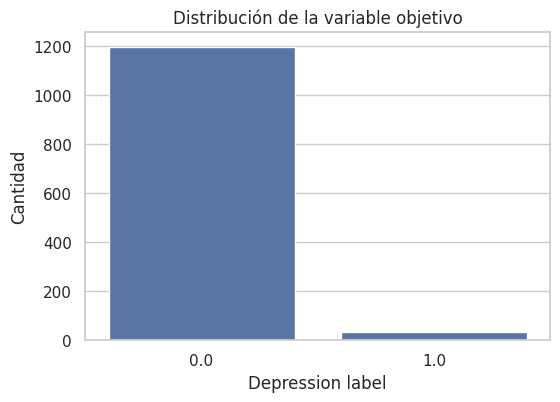

In [8]:
# Distribución de la variable objetivo
print(df["depression_label"].value_counts(dropna=False))
print("\nProporción:")
print(df["depression_label"].value_counts(normalize=True, dropna=False))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="depression_label")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Depression label")
plt.ylabel("Cantidad")
plt.show()

In [9]:
# Identificación de variables numéricas y categóricas
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numéricas:", numeric_cols)
print("Variables categóricas:", categorical_cols)

Variables numéricas: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
Variables categóricas: ['gender', 'platform_usage', 'social_interaction_level']


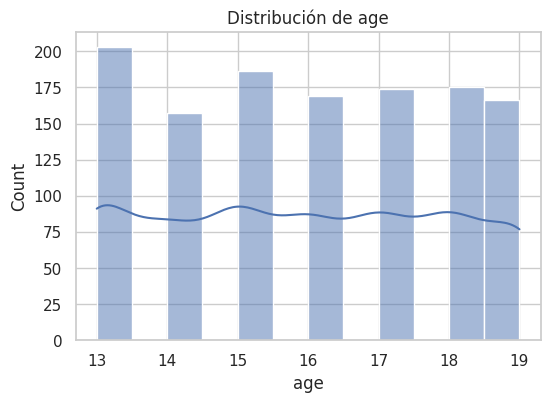

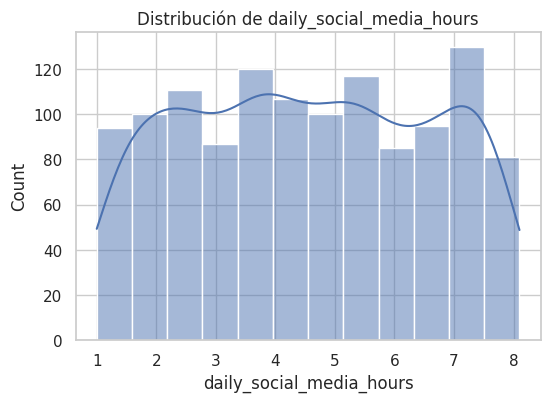

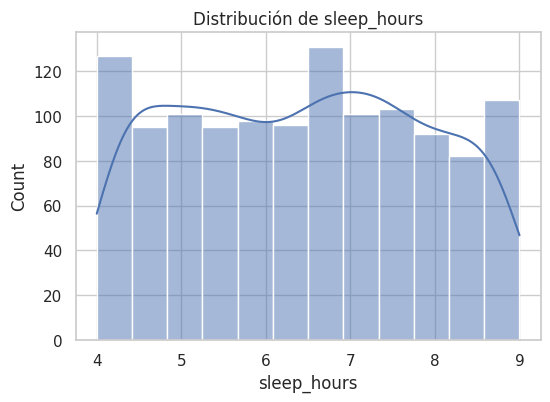

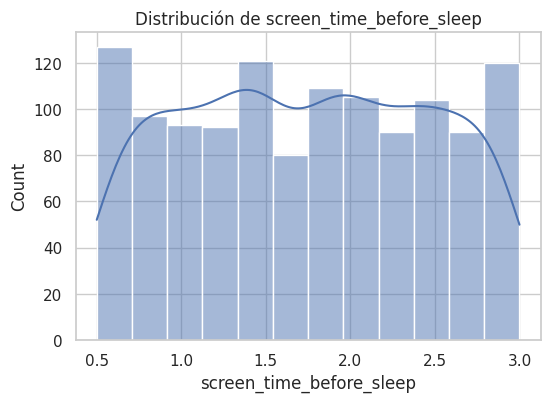

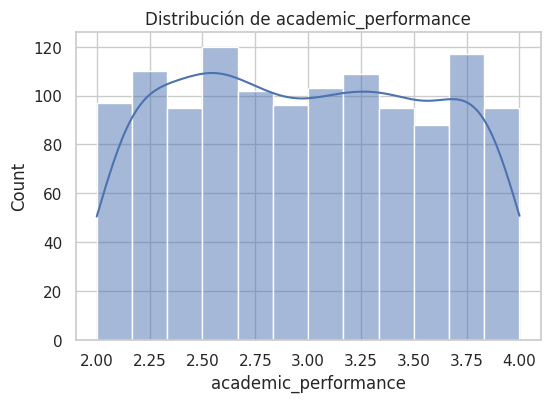

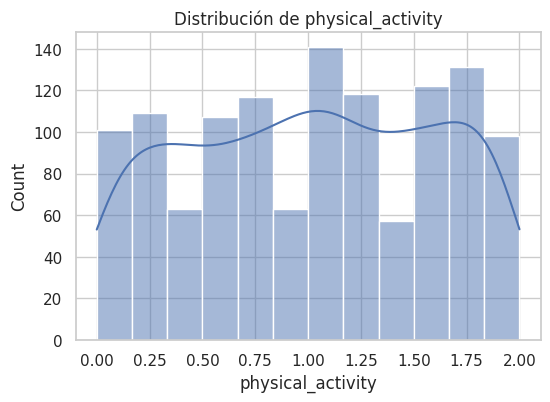

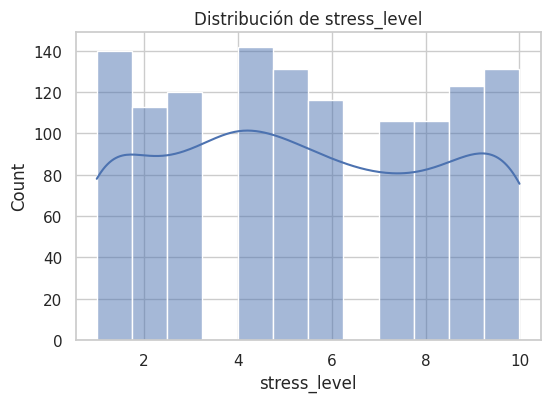

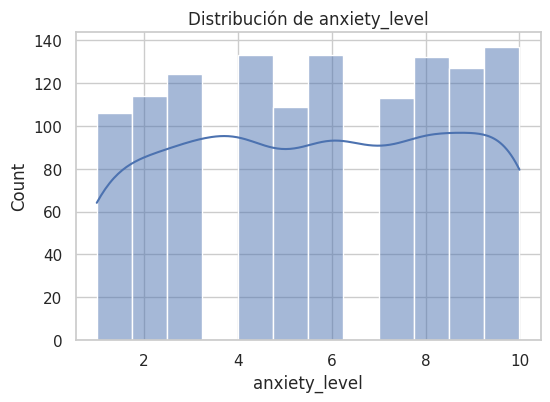

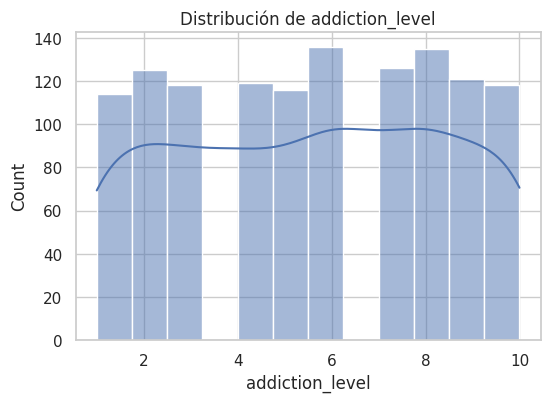

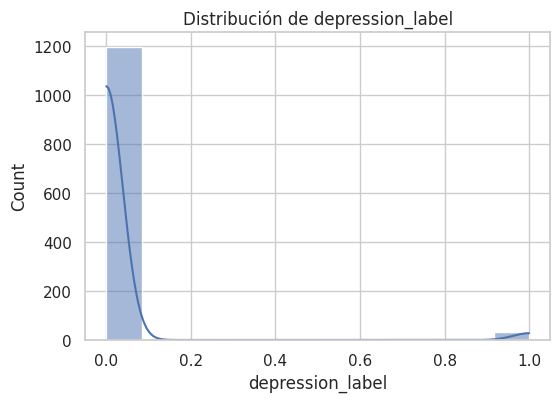

In [10]:
# Histogramas de variables numéricas
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

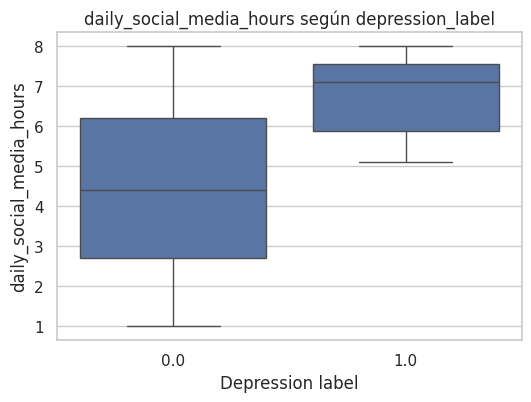

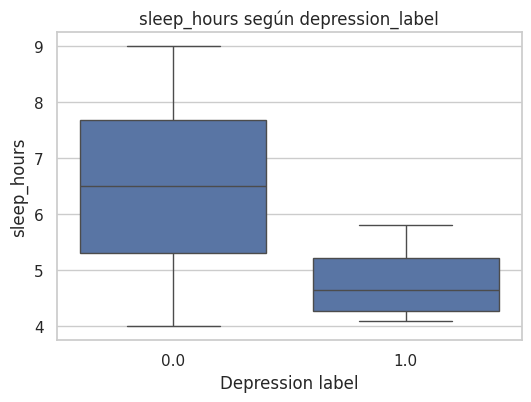

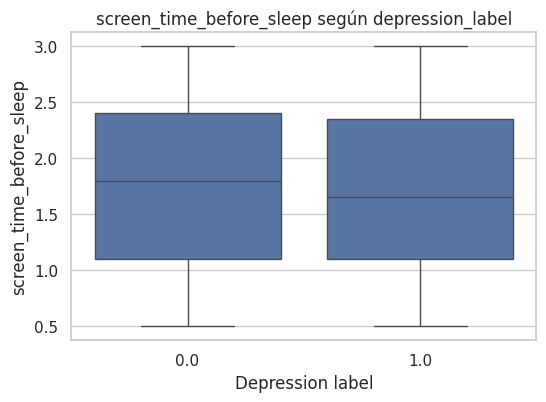

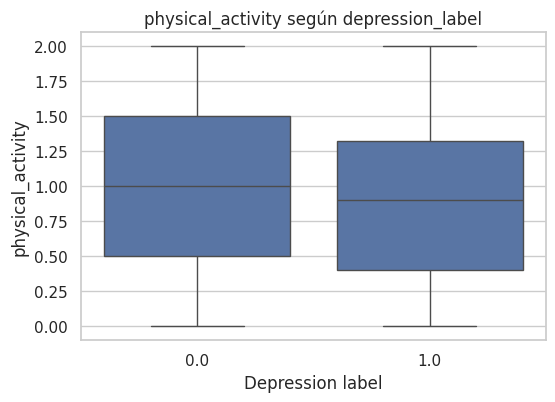

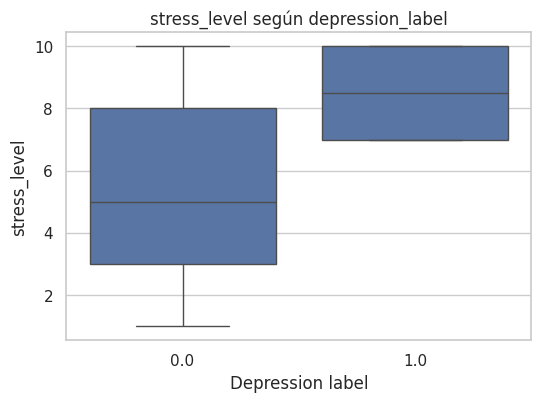

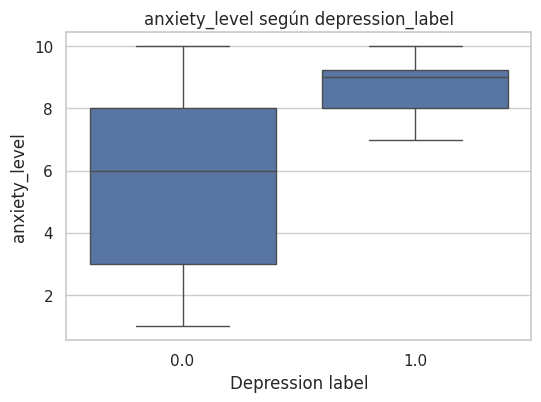

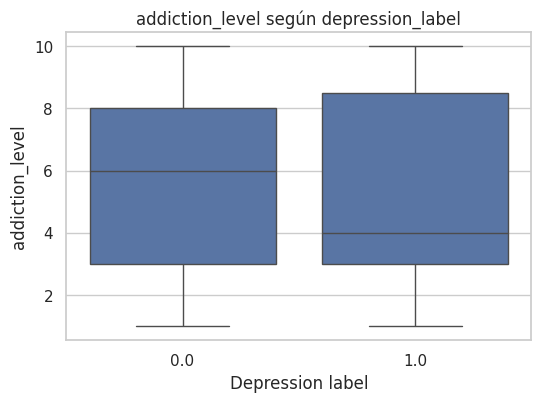

In [11]:
# Relación de variables numéricas con la variable objetivo
key_numeric_cols = [
    "daily_social_media_hours", "sleep_hours", "screen_time_before_sleep",
    "physical_activity", "stress_level", "anxiety_level", "addiction_level"
]

for col in key_numeric_cols:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=df, x="depression_label", y=col)
        plt.title(f"{col} según depression_label")
        plt.xlabel("Depression label")
        plt.ylabel(col)
        plt.show()

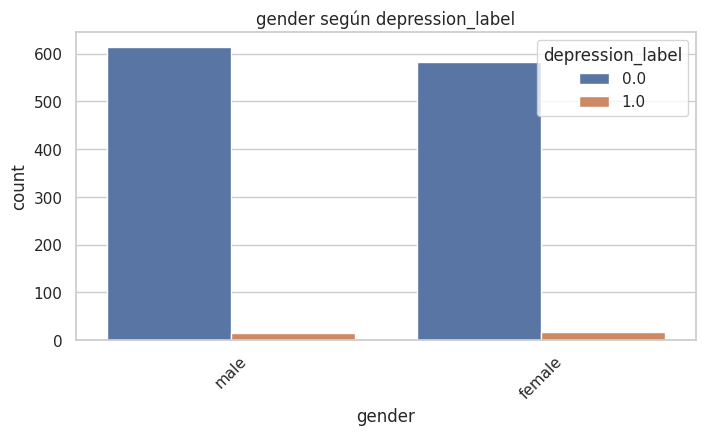

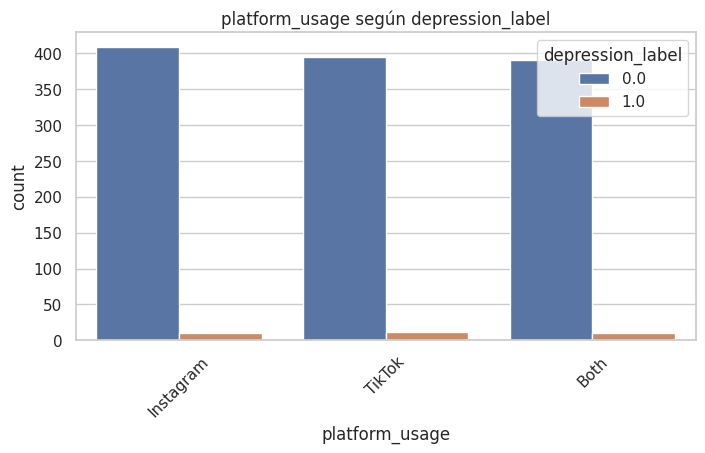

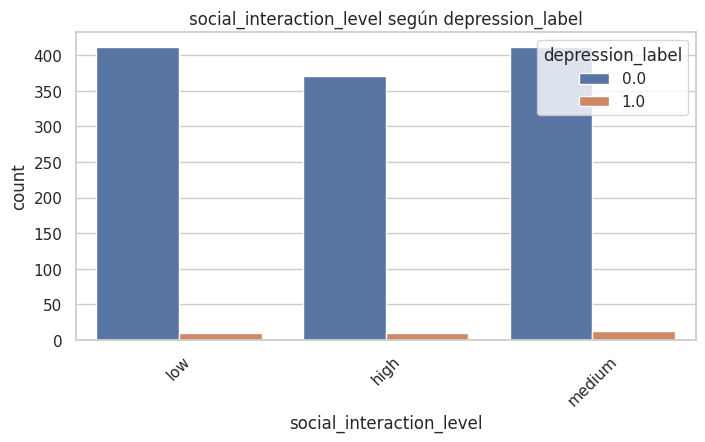

In [12]:
# Análisis de variables categóricas contra la variable objetivo
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="depression_label")
    plt.title(f"{col} según depression_label")
    plt.xticks(rotation=45)
    plt.show()

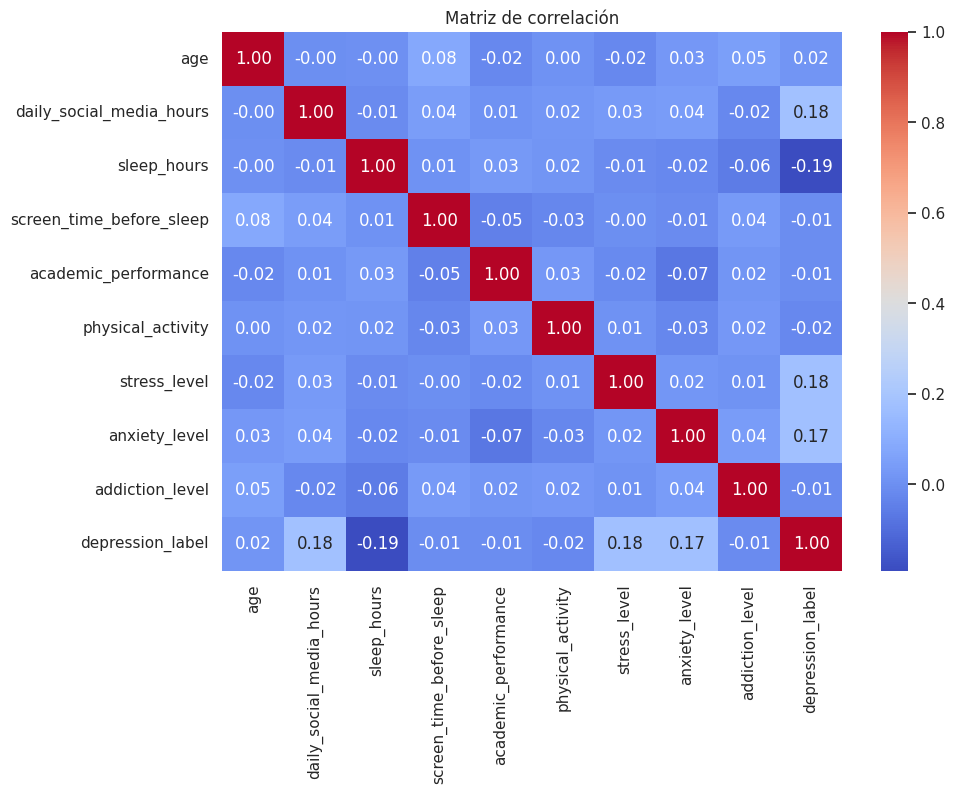

In [13]:
# Matriz de correlación para variables numéricas
plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

### Interpretación del EDA

En el análisis exploratorio se debe observar especialmente:

- Si la variable objetivo está balanceada o desbalanceada.
- Si variables como `stress_level`, `anxiety_level`, `sleep_hours` o `addiction_level` muestran diferencias entre las clases.
- Si existen valores faltantes que deban ser tratados.
- Si las variables categóricas requieren codificación antes del modelamiento.

## 5. Preparación de datos

Se realizará:

1. Eliminación de filas sin variable objetivo.
2. Separación de variables predictoras y variable objetivo.
3. Separación train/test.
4. Imputación de valores faltantes.
5. Escalamiento de variables numéricas.
6. Codificación One-Hot de variables categóricas.

In [14]:
# Eliminamos registros sin variable objetivo, ya que no pueden usarse para entrenamiento supervisado
df_model = df.dropna(subset=["depression_label"]).copy()
df_model["depression_label"] = df_model["depression_label"].astype(int)

X = df_model.drop(columns=["depression_label"])
y = df_model["depression_label"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("X:", X.shape)
print("y:", y.shape)
print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

X: (1228, 12)
y: (1228,)
Numéricas: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']
Categóricas: ['gender', 'platform_usage', 'social_interaction_level']


In [15]:
# Separación train/test con estratificación por la variable objetivo
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Distribución train:")
print(y_train.value_counts(normalize=True))
print("Distribución test:")
print(y_test.value_counts(normalize=True))

Train: (982, 12) (982,)
Test: (246, 12) (246,)
Distribución train:
depression_label
0    0.973523
1    0.026477
Name: proportion, dtype: float64
Distribución test:
depression_label
0    0.97561
1    0.02439
Name: proportion, dtype: float64


In [16]:
# OneHotEncoder compatible con diferentes versiones de scikit-learn
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'daily_social_media_hours',
                                  'sleep_hours', 'screen_time_before_sleep',
                                  'academic_performance', 'physical_activity',
                                  'stress_level', 'anxiety_level',
                                  'addiction_level']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'platform_usage',
                                  'social_interaction_level'])])

In [17]:
# Función de evaluación reutilizable
results = []

def evaluate_model(model_name, y_true, y_pred, y_proba=None):
    metrics = {
        "Modelo": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }

    if y_proba is not None:
        try:
            metrics["ROC-AUC"] = roc_auc_score(y_true, y_proba)
        except Exception:
            metrics["ROC-AUC"] = np.nan
    else:
        metrics["ROC-AUC"] = np.nan

    results.append(metrics)

    print(f"===== {model_name} =====")
    print("Matriz de confusión:")
    print(confusion_matrix(y_true, y_pred))
    print("\nReporte de clasificación:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("\nMétricas:")
    print(metrics)

    return metrics

## 6. Modelo con Scikit-learn

Se utiliza un `Pipeline` con preprocesamiento y un modelo `RandomForestClassifier`. Este modelo funciona como línea base de Machine Learning clásico.

In [18]:
sklearn_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        class_weight="balanced",
        max_depth=None
    ))
])

sklearn_model.fit(X_train, y_train)

sk_pred = sklearn_model.predict(X_test)
sk_proba = sklearn_model.predict_proba(X_test)[:, 1]

sk_metrics = evaluate_model("Scikit-learn Random Forest", y_test, sk_pred, sk_proba)

===== Scikit-learn Random Forest =====
Matriz de confusión:
[[240   0]
 [  4   2]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       240
           1       1.00      0.33      0.50         6

    accuracy                           0.98       246
   macro avg       0.99      0.67      0.75       246
weighted avg       0.98      0.98      0.98       246


Métricas:
{'Modelo': 'Scikit-learn Random Forest', 'Accuracy': 0.983739837398374, 'Precision': 1.0, 'Recall': 0.3333333333333333, 'F1-score': 0.5, 'ROC-AUC': np.float64(0.9999999999999999)}


In [19]:
# Importancia de variables del modelo Scikit-learn
fitted_preprocessor = sklearn_model.named_steps["preprocess"]
rf_model = sklearn_model.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
2,num__sleep_hours,0.274327
6,num__stress_level,0.233745
1,num__daily_social_media_hours,0.180542
7,num__anxiety_level,0.179193
4,num__academic_performance,0.029316
5,num__physical_activity,0.024749
3,num__screen_time_before_sleep,0.022014
8,num__addiction_level,0.019603
0,num__age,0.016767
14,cat__social_interaction_level_high,0.003086


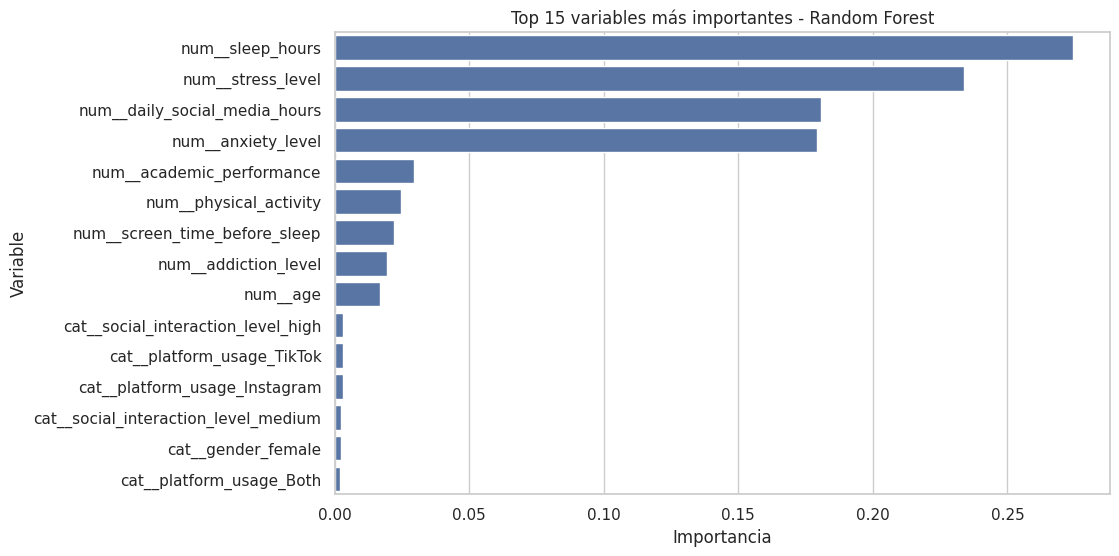

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## 7. Modelo con TensorFlow/Keras

Para Keras se usa la matriz ya preprocesada por el `ColumnTransformer`. La red neuronal tiene capas densas y salida sigmoide para clasificación binaria.

In [21]:
# Transformación de datos para redes neuronales
X_train_processed = fitted_preprocessor.transform(X_train).astype("float32")
X_test_processed = fitted_preprocessor.transform(X_test).astype("float32")

y_train_np = y_train.values.astype("float32")
y_test_np = y_test.values.astype("float32")

print("X_train procesado:", X_train_processed.shape)
print("X_test procesado:", X_test_processed.shape)

X_train procesado: (982, 17)
X_test procesado: (246, 17)


In [22]:
# Pesos de clase para manejar desbalance
classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights = {
    0: class_weights_array[0],
    1: class_weights_array[1]
}
class_weights

{0: np.float64(0.5135983263598326), 1: np.float64(18.884615384615383)}

In [23]:
# Arquitectura Keras
keras_model = keras.Sequential([
    layers.Input(shape=(X_train_processed.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.Precision(name="precision"), keras.metrics.Recall(name="recall")]
)

keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = keras_model.fit(
    X_train_processed,
    y_train_np,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.5771 - loss: 0.7443 - precision: 0.0217 - recall: 0.3043 - val_accuracy: 0.7056 - val_loss: 0.6282 - val_precision: 0.0339 - val_recall: 0.6667
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7567 - loss: 0.6794 - precision: 0.0758 - recall: 0.6522 - val_accuracy: 0.8325 - val_loss: 0.5710 - val_precision: 0.0588 - val_recall: 0.6667
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7924 - loss: 0.6381 - precision: 0.0882 - recall: 0.6522 - val_accuracy: 0.8629 - val_loss: 0.5415 - val_precision: 0.1000 - val_recall: 1.0000
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8217 - loss: 0.5681 - precision: 0.1226 - recall: 0.8261 - val_accuracy: 0.8680 - val_loss: 0.5074 - val_precision: 0.1034 - val_recall: 1.0000
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8268 - loss: 0.5442 - precision: 0.1307 - recall: 0.8696 - val_accuracy: 0.8680 - val_loss: 0.4677

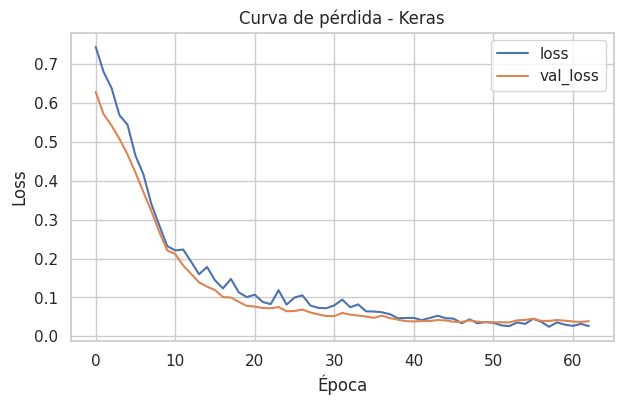

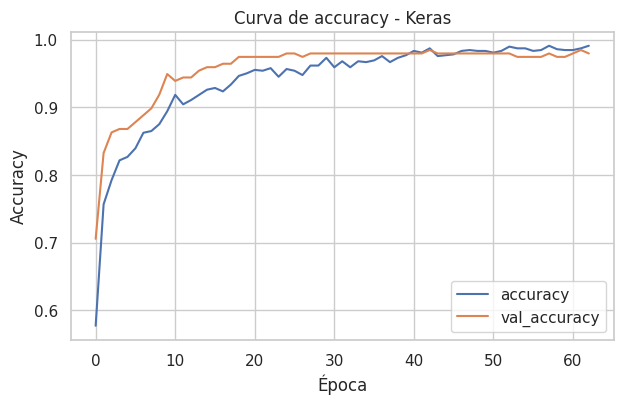

In [25]:
# Curvas de entrenamiento Keras
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Curva de pérdida - Keras")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Curva de accuracy - Keras")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [26]:
# Evaluación Keras
keras_proba = keras_model.predict(X_test_processed).ravel()
keras_pred = (keras_proba >= 0.5).astype(int)

keras_metrics = evaluate_model("TensorFlow/Keras Neural Network", y_test_np, keras_pred, keras_proba)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
===== TensorFlow/Keras Neural Network =====
Matriz de confusión:
[[237   3]
 [  2   4]]

Reporte de clasificación:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       240
         1.0       0.57      0.67      0.62         6

    accuracy                           0.98       246
   macro avg       0.78      0.83      0.80       246
weighted avg       0.98      0.98      0.98       246


Métricas:
{'Modelo': 'TensorFlow/Keras Neural Network', 'Accuracy': 0.9796747967479674, 'Precision': 0.5714285714285714, 'Recall': 0.6666666666666666, 'F1-score': 0.6153846153846154, 'ROC-AUC': np.float64(0.9854166666666666)}


## 8. Modelo con PyTorch

En PyTorch se construye una red neuronal personalizada usando `nn.Module`, `TensorDataset`, `DataLoader`, función de pérdida y ciclo de entrenamiento manual.

In [27]:
# Tensores PyTorch
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np.reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np.reshape(-1, 1), dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(X_train_tensor.shape, y_train_tensor.shape)

torch.Size([982, 17]) torch.Size([982, 1])


In [28]:
# Red neuronal en PyTorch
class MentalHealthNet(nn.Module):
    def __init__(self, input_dim):
        super(MentalHealthNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train_processed.shape[1]
torch_model = MentalHealthNet(input_dim)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_model = torch_model.to(device)

print(torch_model)
print("Device:", device)

MentalHealthNet(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)
Device: cuda


In [29]:
# Pérdida ponderada por desbalance de clases
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
pos_weight_value = negative_count / positive_count

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32).to(device))
optimizer = torch.optim.Adam(torch_model.parameters(), lr=0.001)

print("pos_weight:", pos_weight_value)

pos_weight: 36.76923076923077


In [30]:
# Ciclo de entrenamiento PyTorch
num_epochs = 80
train_losses = []

torch_model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = torch_model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")

Epoch [10/80] - Loss: 0.2874
Epoch [20/80] - Loss: 0.1354
Epoch [30/80] - Loss: 0.0785
Epoch [40/80] - Loss: 0.0612
Epoch [50/80] - Loss: 0.0515
Epoch [60/80] - Loss: 0.0435
Epoch [70/80] - Loss: 0.0260
Epoch [80/80] - Loss: 0.0219


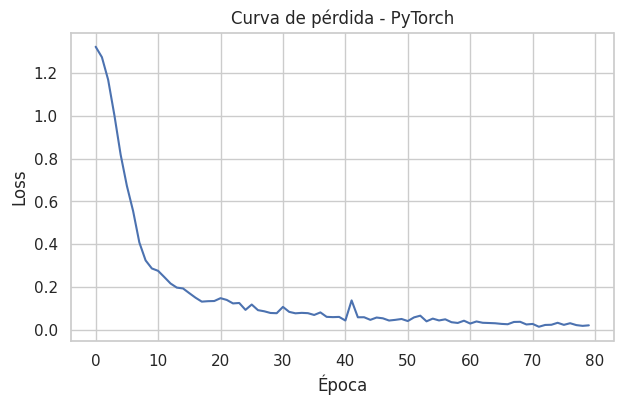

In [31]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses)
plt.title("Curva de pérdida - PyTorch")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

In [32]:
# Evaluación PyTorch
torch_model.eval()
all_probs = []
all_true = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        logits = torch_model(batch_X)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        all_probs.extend(probs)
        all_true.extend(batch_y.numpy().ravel())

pytorch_proba = np.array(all_probs)
pytorch_pred = (pytorch_proba >= 0.5).astype(int)
pytorch_true = np.array(all_true).astype(int)

pytorch_metrics = evaluate_model("PyTorch Neural Network", pytorch_true, pytorch_pred, pytorch_proba)

===== PyTorch Neural Network =====
Matriz de confusión:
[[238   2]
 [  2   4]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       240
           1       0.67      0.67      0.67         6

    accuracy                           0.98       246
   macro avg       0.83      0.83      0.83       246
weighted avg       0.98      0.98      0.98       246


Métricas:
{'Modelo': 'PyTorch Neural Network', 'Accuracy': 0.983739837398374, 'Precision': 0.6666666666666666, 'Recall': 0.6666666666666666, 'F1-score': 0.6666666666666666, 'ROC-AUC': np.float64(0.9888888888888888)}


## 9. Comparación final de modelos

In [33]:
comparison_df = pd.DataFrame(results)
comparison_df

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Scikit-learn Random Forest,0.983740,1.000000,0.333333,0.500000,1.000000
1,TensorFlow/Keras Neural Network,0.979675,0.571429,0.666667,0.615385,0.985417
2,PyTorch Neural Network,0.983740,0.666667,0.666667,0.666667,0.988889


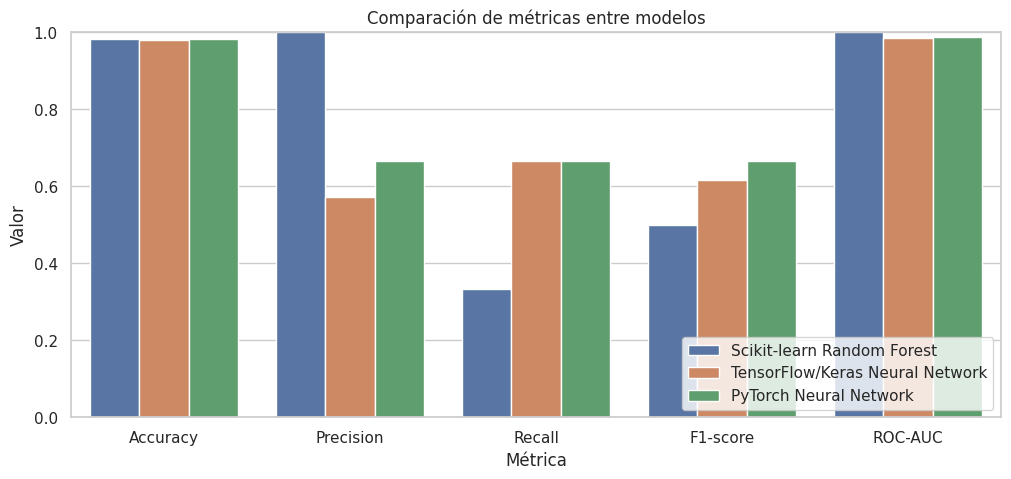

In [34]:
# Comparación visual de métricas
comparison_plot_df = comparison_df.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(12, 5))
sns.barplot(data=comparison_plot_df, x="Métrica", y="Valor", hue="Modelo")
plt.title("Comparación de métricas entre modelos")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

In [35]:
# Mejor modelo según F1-score
best_model = comparison_df.sort_values("F1-score", ascending=False).iloc[0]
print("Mejor modelo según F1-score:")
print(best_model)

Mejor modelo según F1-score:
Modelo       PyTorch Neural Network
Accuracy                    0.98374
Precision                  0.666667
Recall                     0.666667
F1-score                   0.666667
ROC-AUC                    0.988889
Name: 2, dtype: object


## Conclusión final

Durante el desarrollo del proyecto se implementaron tres enfoques de Machine Learning y Deep Learning para la predicción de indicadores asociados a depresión adolescente utilizando variables relacionadas con hábitos digitales, sueño, actividad física, estrés y ansiedad.

Inicialmente se identificó un fuerte desbalance en la variable objetivo, donde la mayoría de registros pertenecen a adolescentes sin indicador de depresión. Debido a esta característica, la métrica Accuracy no fue considerada suficiente para evaluar el desempeño de los modelos, dando mayor importancia al Recall y F1-score de la clase positiva.

El modelo Random Forest implementado con Scikit-learn obtuvo el mayor Accuracy (98.37%) y Precision (100%). Esto significa que cuando el modelo predice un caso positivo tiene una alta confiabilidad. Sin embargo, obtuvo un Recall de 33.33%, indicando que no logró identificar una parte importante de los casos asociados a posibles indicadores de depresión.

La red neuronal desarrollada con TensorFlow/Keras obtuvo un mejor equilibrio entre las métricas, alcanzando un Recall de 66.67% y un F1-score de 61.53%. Esto indica una mayor capacidad para detectar casos positivos sin perder demasiado rendimiento general.

El modelo desarrollado con PyTorch presentó un comportamiento similar a TensorFlow/Keras, obteniendo un Recall de 66.67% y un F1-score de 66.67%. Aunque su precisión fue menor, demostró una buena capacidad para detectar la clase minoritaria mediante una arquitectura personalizada y un ciclo de entrenamiento controlado manualmente.

Los valores altos de ROC-AUC en los tres modelos indican que todos lograron diferenciar correctamente patrones entre ambas clases. Sin embargo, considerando que el objetivo del problema es identificar adolescentes con posibles señales de depresión, el modelo TensorFlow/Keras representa el mejor equilibrio entre detección y precisión.

En conclusión, aunque Random Forest logró excelentes resultados generales, los modelos basados en redes neuronales fueron más adecuados para este escenario debido a su mayor capacidad para reconocer la clase minoritaria. Este análisis demuestra la importancia de seleccionar métricas adecuadas según el contexto del problema y no depender únicamente del Accuracy.